# Notebook 1 — Exploração de Dados e Análise de Drift

## Aula 6: Monitoramento Contínuo e Data SLOs em Produção

### Objetivos

1. Carregar e explorar o dataset sintético de crédito digital (fintech).
2. Analisar as distribuições das features de referência vs produção.
3. Visualizar o **Data Drift** introduzido nas features `idade`, `renda_mensal` e `score_credito`.
4. Calcular estatísticas descritivas e taxas de valores ausentes.

### Conexão com o Documento 04

> *"Imagine que uma fintech acaba de lançar um modelo de machine learning para aprovação
> instantânea de crédito. No início, tudo corre bem: o modelo apresenta alta acurácia
> nos testes e impulsiona os negócios. Porém, com o passar do tempo, os clientes mudam
> de comportamento, surgem novos dados de mercado, a economia oscila."*
> — DOCUMENTO_AULA_6.md, seção 'O Que Vem Por Aí?'

### Vídeo Relacionado

- **Vídeo 6.1**: Por que monitorar ML em produção; conceito de Data SLOs e SLIs; caso fintech

In [1]:
# Imports
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import ks_2samp

# Adicionar diretório pai ao path para importar src/
sys.path.insert(0, str(Path.cwd().parent))

from src.data_preprocessing import DataPreprocessor

# Configurações de visualização
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12
sns.set_style("whitegrid")

%matplotlib inline

## 1. Geração e Carregamento dos Dados

Geramos um dataset sintético que simula o cenário da fintech de crédito digital.
O dataset contém **5.000 amostras de referência** (treino) e **5.000 amostras
de produção** com drift introduzido, conforme descrito na seção
'Data Drift & Concept Drift' do DOCUMENTO_AULA_6.md.

In [2]:
# Gerar dataset (se necessário) e carregar
preprocessor = DataPreprocessor(random_state=42)

try:
    data = preprocessor.load_data()
except FileNotFoundError:
    print("Dataset não encontrado. Gerando...")
    DataPreprocessor.generate_dataset()
    data = preprocessor.load_data()

print(f"Shape: {data.shape}")
data.head()

Dados carregados: 10000 amostras, 12 colunas
Shape: (10000, 12)


,idade,renda_mensal,score_credito,tempo_emprego,valor_emprestimo,taxa_utilizacao_credito,num_parcelas,historico_atrasos,saldo_conta,qtd_dependentes,is_production,target
0,39.967142,5773.260364,498.225790,2.468165,10412.160805,0.196728,12,0,1182.322589,1,0,0
1,33.617357,5637.910027,554.175081,0.076114,5992.121886,0.184866,12,3,1684.266233,2,0,0
2,41.476885,1926.548737,510.392841,11.427316,4174.375538,0.313087,24,0,1318.372682,0,0,0
3,50.230299,6222.505055,616.562707,3.743765,6759.697932,0.237182,36,1,1507.076595,0,0,0
4,32.658466,14563.348365,779.576780,9.479013,19643.163985,0.381142,24,3,3819.402659,2,0,0


## 2. Separação Referência vs Produção

O campo `is_production` indica se a amostra pertence ao conjunto de referência
(treino original) ou à produção (dados novos com possível drift).

Conforme o DOCUMENTO_AULA_6.md:
> *"Data Drift: mudança nas distribuições das features de entrada ao longo do tempo."*

In [3]:
# Separar dados de referência e produção
df_ref, df_prod = preprocessor.split_reference_production(data)

print(f"Referência: {len(df_ref)} amostras")
print(f"Produção:   {len(df_prod)} amostras")
print(f"\nTarget (referência): {df_ref['target'].mean():.1%} inadimplência")
print(f"Target (produção):   {df_prod['target'].mean():.1%} inadimplência")

Referência: 5000 | Produção: 5000
Referência: 5000 amostras
Produção:   5000 amostras

Target (referência): 2.5% inadimplência
Target (produção):   6.4% inadimplência


## 3. Estatísticas Descritivas

Comparamos as estatísticas descritivas entre referência e produção para
identificar mudanças nas distribuições (Data Drift).

In [4]:
# Estatísticas descritivas — referência
print("=" * 60)
print("DADOS DE REFERÊNCIA")
print("=" * 60)
df_ref.describe().round(2)

DADOS DE REFERÊNCIA


,idade,renda_mensal,score_credito,tempo_emprego,valor_emprestimo,taxa_utilizacao_credito,num_parcelas,historico_atrasos,saldo_conta,qtd_dependentes,is_production,target
count,4980.00,4976.00,4973.00,4967.00,5000.00,5000.00,5000.00,5000.00,4967.00,5000.00,5000.0,5000.00
mean,35.24,10927.56,601.51,5.20,15868.14,0.28,29.13,0.80,4822.83,1.20,0.0,0.02
std,9.56,9379.91,149.18,5.19,10234.76,0.16,18.16,0.92,6449.29,1.08,0.0,0.16
min,18.00,1000.00,93.66,0.00,1321.04,0.00,6.00,0.00,87.07,0.00,0.0,0.00
25%,28.42,4675.72,500.87,1.53,8776.29,0.16,12.00,0.00,1502.82,0.00,0.0,0.00
50%,35.13,7983.22,601.38,3.59,13324.11,0.27,24.00,1.00,2915.19,1.00,0.0,0.00
75%,41.66,13940.14,701.35,7.14,19956.02,0.39,48.00,1.00,5644.53,2.00,0.0,0.00
max,70.00,50000.00,1000.00,40.00,116635.62,0.84,60.00,6.00,112782.55,7.00,0.0,1.00


In [5]:
# Estatísticas descritivas — produção
print("=" * 60)
print("DADOS DE PRODUÇÃO")
print("=" * 60)
df_prod.describe().round(2)

DADOS DE PRODUÇÃO


,idade,renda_mensal,score_credito,tempo_emprego,valor_emprestimo,taxa_utilizacao_credito,num_parcelas,historico_atrasos,saldo_conta,qtd_dependentes,is_production,target
count,4905.00,4906.00,4905.00,4893.00,5000.00,5000.00,5000.00,5000.00,4905.00,5000.00,5000.0,5000.00
mean,40.35,9251.29,549.98,4.97,15976.02,0.28,29.04,1.51,4846.77,1.16,1.0,0.06
std,9.94,8144.28,153.19,5.02,10579.82,0.16,18.23,1.22,6117.30,1.09,0.0,0.24
min,18.00,1000.00,0.00,0.00,1715.09,0.00,6.00,0.00,103.39,0.00,1.0,0.00
25%,33.50,4037.84,447.63,1.38,8806.19,0.16,12.00,1.00,1494.34,0.00,1.0,0.00
50%,40.19,6740.43,547.05,3.42,13331.26,0.26,24.00,1.00,2882.91,1.00,1.0,0.00
75%,47.10,11576.54,652.67,6.82,20206.03,0.38,48.00,2.00,5796.57,2.00,1.0,0.00
max,70.00,50000.00,1000.00,40.00,182398.79,0.85,60.00,8.00,77277.12,7.00,1.0,1.00


## 4. Análise de Valores Ausentes (Quality Drift)

Implementa verificação de qualidade conforme **Snippet 3** do DOCUMENTO_AULA_6.md:

```python
missing_rate = df.isnull().mean()
if (missing_rate > 0.01).any():
    alert(f"Alerta: colunas com +1% de valores ausentes: ...")
```

O SLO de qualidade define **máximo 1% de valores ausentes** por coluna.

In [6]:
# Comparar taxas de valores ausentes
missing_ref = df_ref.isnull().mean() * 100
missing_prod = df_prod.isnull().mean() * 100

missing_comparison = pd.DataFrame({
    "Referência (%)": missing_ref,
    "Produção (%)": missing_prod,
    "SLO (1%)": 1.0,
}).round(3)

# Destacar colunas que violam o SLO
missing_comparison["Viola SLO?"] = missing_comparison["Produção (%)"] > 1.0

print("Taxa de valores ausentes por coluna (%):\n")
missing_comparison[missing_comparison["Produção (%)"] > 0]

Taxa de valores ausentes por coluna (%):



,Referência (%),Produção (%),SLO (1%),Viola SLO?
idade,0.40,1.90,1.0,True
renda_mensal,0.48,1.88,1.0,True
score_credito,0.54,1.90,1.0,True
tempo_emprego,0.66,2.14,1.0,True
saldo_conta,0.66,1.90,1.0,True


## 5. Visualização de Distribuições — Data Drift

Conforme a seção 'Data Drift & Concept Drift' do DOCUMENTO_AULA_6.md:

> *"Data Drift refere-se às mudanças nas características estatísticas
> dos dados de entrada ao longo do tempo. Por exemplo, no caso de
> aprovação de crédito, a proporção de solicitantes de determinadas
> faixas etárias ou níveis de renda pode se alterar."*

Visualizamos as features onde introduzimos drift: `idade` (+5 anos),
`renda_mensal` (−15%) e `score_credito` (−50 pontos).

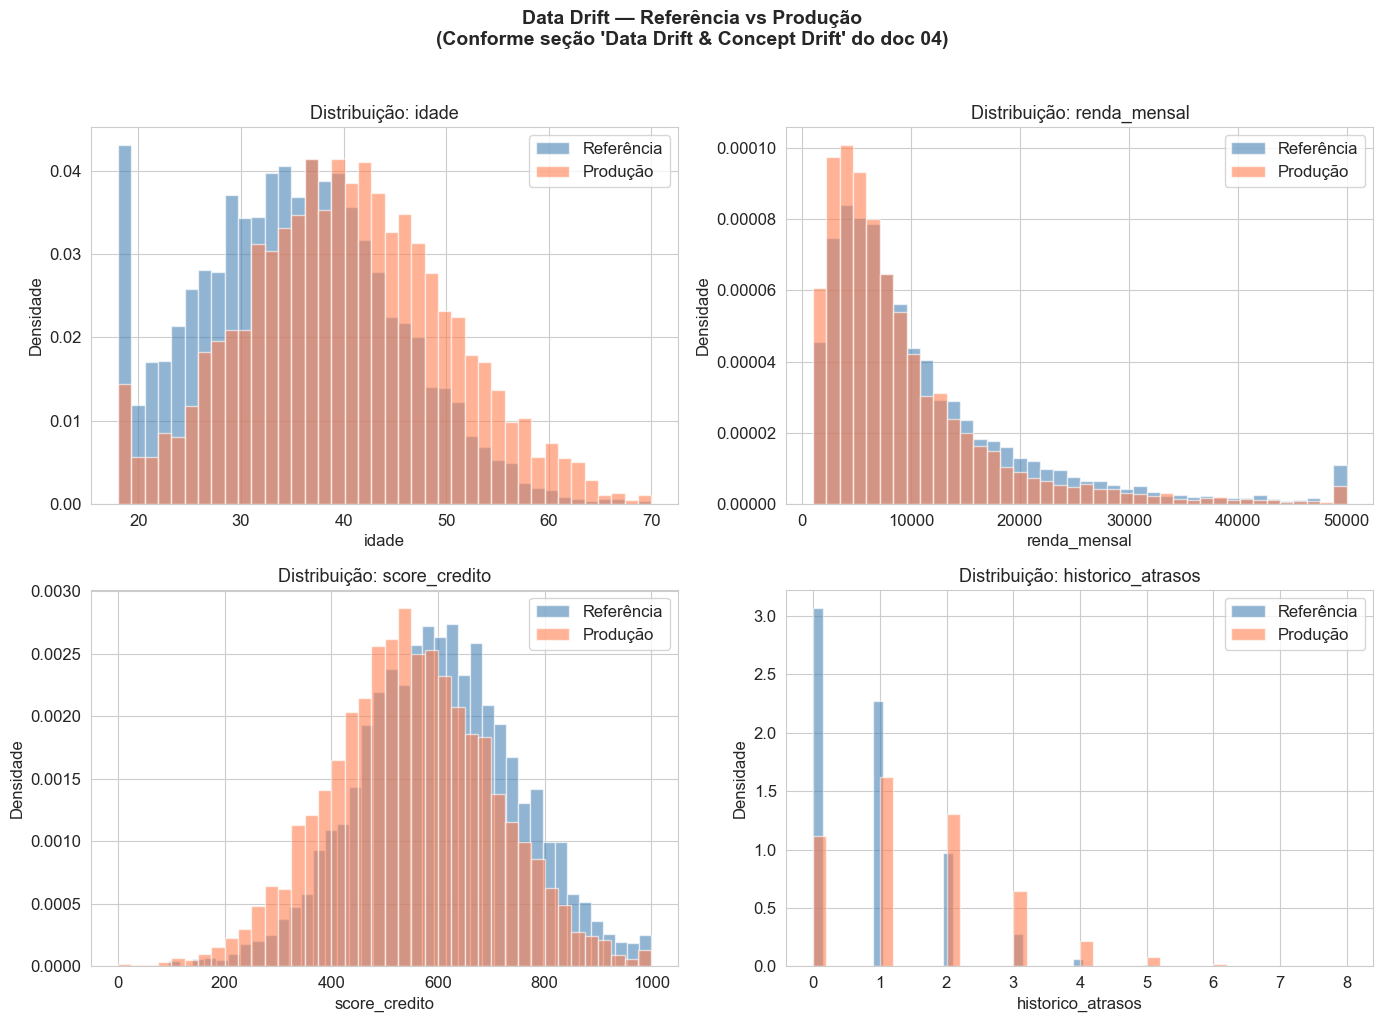

In [7]:
# Features com drift introduzido
drift_features = ["idade", "renda_mensal", "score_credito", "historico_atrasos"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, feature in zip(axes.flatten(), drift_features):
    ax.hist(
        df_ref[feature].dropna(), bins=40, alpha=0.6,
        label="Referência", color="steelblue", density=True,
    )
    ax.hist(
        df_prod[feature].dropna(), bins=40, alpha=0.6,
        label="Produção", color="coral", density=True,
    )
    ax.set_title(f"Distribuição: {feature}", fontsize=13)
    ax.set_xlabel(feature)
    ax.set_ylabel("Densidade")
    ax.legend()

plt.suptitle(
    "Data Drift — Referência vs Produção\n"
    "(Conforme seção 'Data Drift & Concept Drift' do doc 04)",
    fontsize=14, fontweight="bold", y=1.02,
)
plt.tight_layout()
plt.savefig("../outputs/figures/drift_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Teste de Kolmogorov-Smirnov para Detecção de Drift

Implementa **Snippet 2** do DOCUMENTO_AULA_6.md:

```python
_, p_val = ks_2samp(base['idade'], novos['idade'])
if p_val < 0.05:
    alert(f"Alerta: deriva detectada na distribuição de 'idade' (p={p_val:.3f})")
```

> *"Usando um teste estatístico de Kolmogorov-Smirnov (K-S), podemos comparar
> a distribuição de frequências de uma feature nas amostras recente e original."*

In [8]:
# Teste KS para todas as features numéricas
feature_cols = [
    "idade", "renda_mensal", "score_credito", "tempo_emprego",
    "valor_emprestimo", "taxa_utilizacao_credito", "num_parcelas",
    "historico_atrasos", "saldo_conta", "qtd_dependentes",
]

ks_results = []
for feature in feature_cols:
    ref_clean = df_ref[feature].dropna()
    prod_clean = df_prod[feature].dropna()
    stat, p_value = ks_2samp(ref_clean, prod_clean)
    drift_detected = p_value < 0.05
    ks_results.append({
        "Feature": feature,
        "KS Statistic": round(stat, 4),
        "p-value": round(p_value, 6),
        "Drift Detectado?": "SIM" if drift_detected else "Não",
    })

ks_df = pd.DataFrame(ks_results)
print("Resultados do Teste KS — Detecção de Drift\n")
ks_df

Resultados do Teste KS — Detecção de Drift



,Feature,KS Statistic,p-value,Drift Detectado?
0,idade,0.2031,0.000000,SIM
1,renda_mensal,0.0886,0.000000,SIM
2,score_credito,0.1433,0.000000,SIM
3,tempo_emprego,0.0291,0.030035,SIM
4,valor_emprestimo,0.0146,0.660939,Não
5,taxa_utilizacao_credito,0.0182,0.379103,Não
6,num_parcelas,0.0126,0.822301,Não
7,historico_atrasos,0.2556,0.000000,SIM
8,saldo_conta,0.0142,0.694925,Não
9,qtd_dependentes,0.0234,0.129393,Não


## 7. Population Stability Index (PSI)

Implementa a fórmula do PSI conforme a seção 'Data Drift & Concept Drift':

$$
PSI = \sum_{i=1}^{n} (P_i - Q_i) \ln\!\left(\frac{P_i}{Q_i}\right)
$$

Valores de PSI:
- **< 0.10** → Sem mudança significativa
- **0.10 – 0.25** → Mudança moderada
- **> 0.25** → Mudança severa (requer investigação)

In [9]:
from src.model import SLOMonitor

# Calcular PSI para cada feature
psi_results = []
for feature in feature_cols:
    ref_vals = df_ref[feature].dropna().values
    prod_vals = df_prod[feature].dropna().values
    psi_value = SLOMonitor.calculate_psi(ref_vals, prod_vals)

    if psi_value < 0.10:
        severity = "Baixo"
    elif psi_value < 0.25:
        severity = "Moderado"
    else:
        severity = "SEVERO"

    psi_results.append({
        "Feature": feature,
        "PSI": round(psi_value, 4),
        "Severidade": severity,
    })

psi_df = pd.DataFrame(psi_results).sort_values("PSI", ascending=False)
print("Population Stability Index (PSI) por Feature\n")
psi_df

Population Stability Index (PSI) por Feature



,Feature,PSI,Severidade
7,historico_atrasos,0.3860,SEVERO
0,idade,0.2599,SEVERO
2,score_credito,0.1110,Moderado
1,renda_mensal,0.0434,Baixo
6,num_parcelas,0.0051,Baixo
3,tempo_emprego,0.0051,Baixo
8,saldo_conta,0.0038,Baixo
4,valor_emprestimo,0.0031,Baixo
5,taxa_utilizacao_credito,0.0028,Baixo
9,qtd_dependentes,0.0028,Baixo


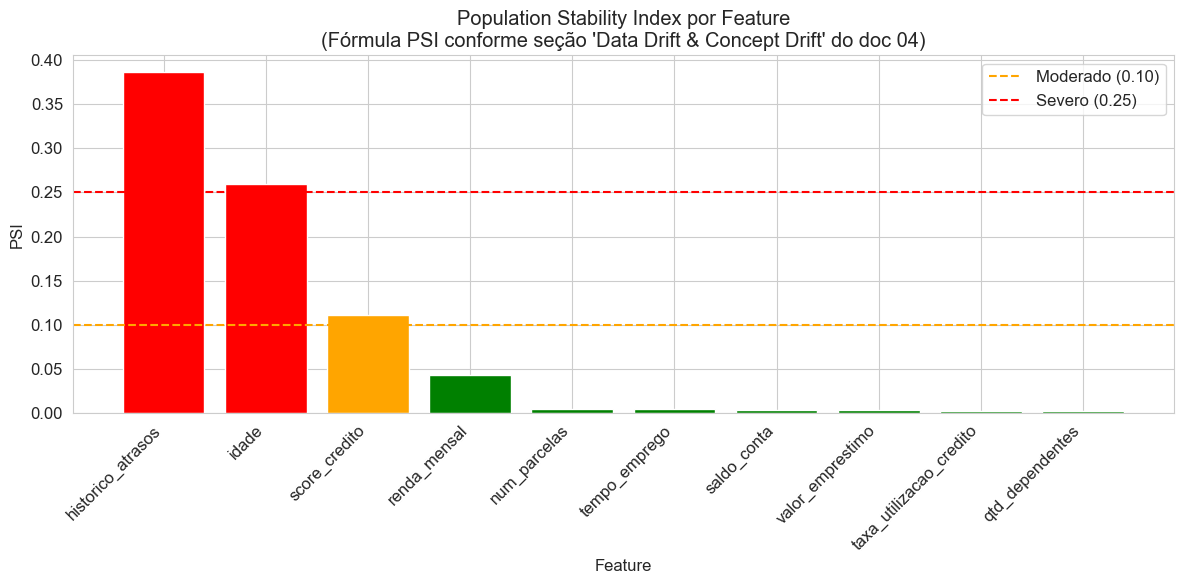

In [10]:
# Gráfico de barras do PSI
fig, ax = plt.subplots(figsize=(12, 6))

colors = [
    "green" if row["PSI"] < 0.10
    else "orange" if row["PSI"] < 0.25
    else "red"
    for _, row in psi_df.iterrows()
]

bars = ax.bar(psi_df["Feature"], psi_df["PSI"], color=colors)
ax.axhline(y=0.10, color="orange", linestyle="--", label="Moderado (0.10)")
ax.axhline(y=0.25, color="red", linestyle="--", label="Severo (0.25)")
ax.set_xlabel("Feature")
ax.set_ylabel("PSI")
ax.set_title(
    "Population Stability Index por Feature\n"
    "(Fórmula PSI conforme seção 'Data Drift & Concept Drift' do doc 04)"
)
ax.legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../outputs/figures/psi_by_feature.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Análise do Target (Concept Drift)

Conforme o DOCUMENTO_AULA_6.md:
> *"Concept Drift está relacionado à mudança na relação entre as
> variáveis de entrada e a variável alvo ao longo do tempo."*

Verificamos se a taxa de inadimplência mudou entre referência e produção.

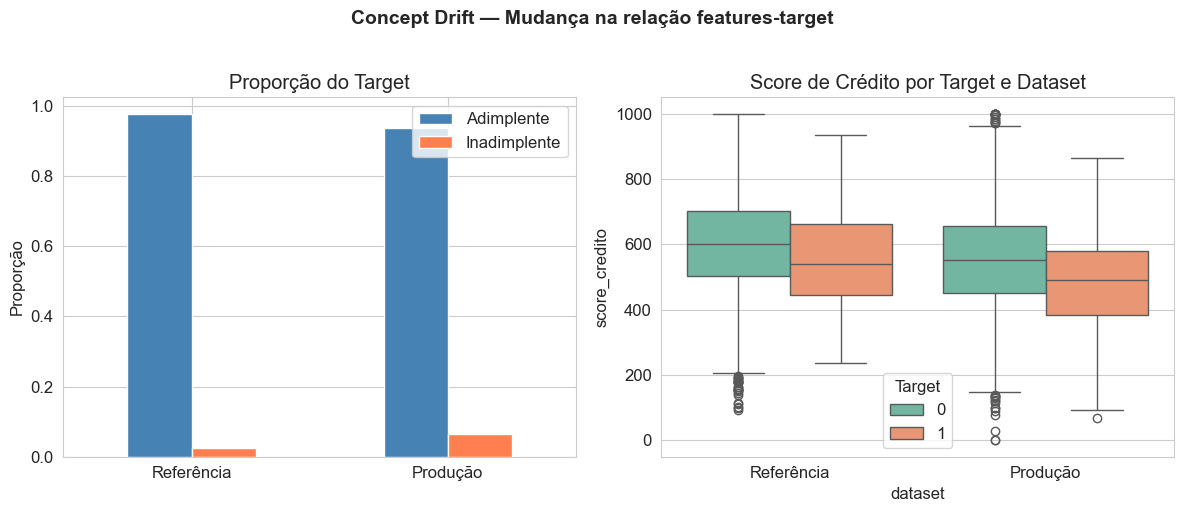

In [11]:
# Comparar taxa de inadimplência (concept drift)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Proporção do target
ref_target = df_ref["target"].value_counts(normalize=True)
prod_target = df_prod["target"].value_counts(normalize=True)

comparison_df = pd.DataFrame({
    "Referência": ref_target,
    "Produção": prod_target,
}).T

comparison_df.columns = ["Adimplente", "Inadimplente"]
comparison_df.plot(kind="bar", ax=axes[0], color=["steelblue", "coral"])
axes[0].set_title("Proporção do Target")
axes[0].set_ylabel("Proporção")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend()

# Boxplot de score_credito por target
combined = pd.concat([
    df_ref.assign(dataset="Referência"),
    df_prod.assign(dataset="Produção"),
])
sns.boxplot(
    data=combined, x="dataset", y="score_credito",
    hue="target", ax=axes[1], palette="Set2",
)
axes[1].set_title("Score de Crédito por Target e Dataset")
axes[1].legend(title="Target")

plt.suptitle(
    "Concept Drift — Mudança na relação features-target",
    fontsize=14, fontweight="bold", y=1.02,
)
plt.tight_layout()
plt.savefig("../outputs/figures/concept_drift_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Matriz de Correlação

Verificamos se as correlações entre features e target mudaram
entre referência e produção — outro sinal de concept drift.

In [12]:
# Correlação com target — referência vs produção
corr_ref = df_ref[feature_cols + ["target"]].corr()["target"].drop("target")
corr_prod = df_prod[feature_cols + ["target"]].corr()["target"].drop("target")

corr_comparison = pd.DataFrame({
    "Correlação Referência": corr_ref,
    "Correlação Produção": corr_prod,
    "Delta": (corr_prod - corr_ref).abs(),
}).round(4).sort_values("Delta", ascending=False)

print("Correlação com target — Referência vs Produção\n")
corr_comparison

Correlação com target — Referência vs Produção



,Correlação Referência,Correlação Produção,Delta
score_credito,-0.0534,-0.1131,0.0597
historico_atrasos,0.0273,0.0580,0.0307
taxa_utilizacao_credito,0.0525,0.0735,0.0210
num_parcelas,-0.0004,-0.0164,0.0160
tempo_emprego,-0.0229,-0.0344,0.0115
idade,0.0281,0.0397,0.0115
saldo_conta,-0.0072,-0.0158,0.0086
qtd_dependentes,0.0288,0.0209,0.0080
valor_emprestimo,0.0180,0.0199,0.0019
renda_mensal,-0.0633,-0.0628,0.0005


## Resumo

### O que aprendemos neste notebook:

1. **Dataset de crédito digital**: 10.000 amostras (5K referência + 5K produção)
   com drift introduzido em `idade`, `renda_mensal`, `score_credito` e `historico_atrasos`.

2. **Data Drift**: Confirmamos via teste KS e PSI que as features com drift
   introduzido apresentam diferenças estatisticamente significativas.

3. **Concept Drift**: A taxa de inadimplência aumentou de ~30% (referência)
   para ~40% (produção), indicando mudança na relação features-target.

4. **Quality Drift**: Dados de produção têm ~2% de missings vs ~0.5% na referência.

### Próximo notebook

No **Notebook 02 (Treinamento)**, treinaremos um modelo de crédito nos dados de
referência e definiremos os SLOs (thresholds de acurácia, drift e qualidade)
que serão monitorados no pipeline de produção.